# Chapter 12 — Bermudan Swaption LSM Pricing

# 1. Introduction
## Longstaff-Schwartz Monte Carlo

This chapter prices Bermudan swaptions using the Longstaff-Schwartz Monte Carlo (LSM) method.

Chapter 11 priced Bermudan swaptions by tree-based backward induction. Chapter 12 solves the same early-exercise problem using simulation and regression.

The core comparison remains:

$$
V(t,r)=\max(E(t,r), C(t,r))
$$

where $E(t,r)$ is the immediate exercise value and $C(t,r)$ is the continuation value.

In LSM, the continuation value is estimated by regression on simulated paths.

---

# 2. Import Libraries

This chapter reuses Chapter 09 and Chapter 11 modules.

Required reused modules:

```text
09_hull_white_short_rate_model/python/
├── market_data.py
├── hull_white_model.py
└── bond_pricing.py

11_bermudan_swaption_tree_pricing/python/
├── bermudan_swaption.py
├── hull_white_tree.py
└── tree_pricer.py
```

In [1]:
import sys
import os

# Chapter 12 files
sys.path.append("../python")

# Reuse Chapter 09 Hull-White model and curve utilities
sys.path.append("../../09_hull_white_short_rate_model/python")

# Reuse Chapter 11 Bermudan swaption and tree pricer
sys.path.append("../../11_bermudan_swaption_tree_pricing/python")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from market_data import (
    load_curve_data,
    curve_to_dataframe
)

from hull_white_model import (
    HullWhiteModel
)

from bermudan_swaption import (
    BermudanSwaption
)

from hull_white_tree import (
    HullWhiteBinomialTree
)

from tree_pricer import (
    BermudanSwaptionTreePricer
)

from lsm_path_simulation import (
    simulate_hull_white_paths_for_lsm
)

from lsm_bermudan_pricer import (
    BermudanSwaptionLSMPricer
)

from diagnostics import (
    print_lsm_summary,
    print_exercise_summary,
    regression_diagnostics_table,
    compare_tree_lsm_prices
)

from plotting import (
    plot_rate_paths,
    plot_exercise_distribution,
    plot_price_sensitivity,
    plot_regression_path_counts
)

plt.rcParams["figure.figsize"] = (10, 6)

print("Libraries imported successfully.")

Libraries imported successfully.


## Load Yield Curve

We reuse the USD zero curve from Chapter 09.

In [2]:
curve = load_curve_data(
    "../../09_hull_white_short_rate_model/data/usd_zero_curve.csv"
)

curve_times = np.array([
    0.25, 0.5, 1, 2, 3, 5, 7, 10, 15, 20, 30
])

curve_df = curve_to_dataframe(
    curve,
    curve_times
)

curve_df

,time,discount_factor,zero_rate
0,0.25,0.995012,0.0200
1,0.50,0.989555,0.0210
2,1.00,0.978240,0.0220
3,2.00,0.953134,0.0240
4,3.00,0.927743,0.0250
5,5.00,0.873716,0.0270
6,7.00,0.819140,0.0285
7,10.00,0.740818,0.0300
8,15.00,0.618783,0.0320
9,20.00,0.516851,0.0330


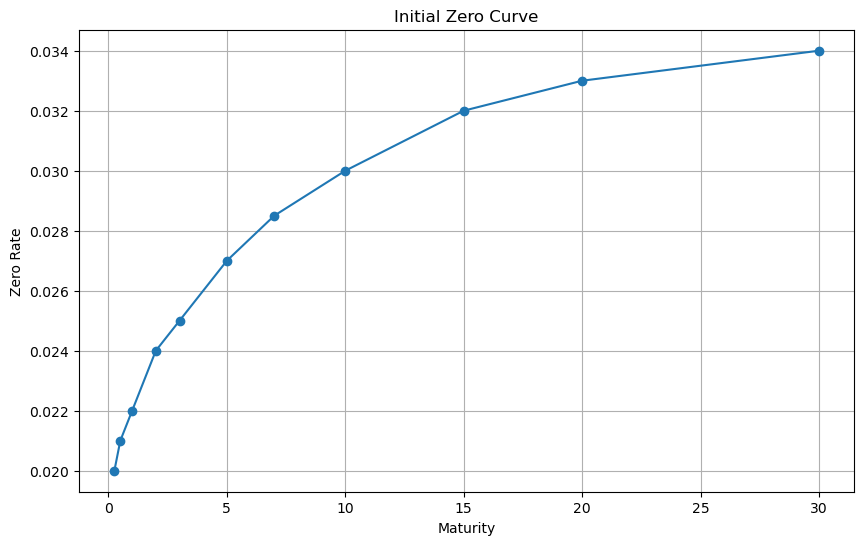

In [3]:
plt.figure()

plt.plot(
    curve_df["time"],
    curve_df["zero_rate"],
    marker="o"
)

plt.title("Initial Zero Curve")
plt.xlabel("Maturity")
plt.ylabel("Zero Rate")
plt.grid()
plt.show()

---
# 3. Hull-White Model Setup

The LSM simulation uses the Chapter 09 one-factor Hull-White model:

$$
dr_t = (\theta(t)-ar_t)dt + \sigma dW_t.
$$

In [4]:
hw_model = HullWhiteModel(
    mean_reversion=0.05,
    volatility=0.01,
    curve=curve
)

r0 = hw_model.instantaneous_forward_rate(
    1e-6
)

print("Initial short-rate proxy:", r0)
print("Theta(2Y):", hw_model.theta(2.0))

Initial short-rate proxy: 0.02000000000000102
Theta(2Y): -0.015468980753120226


---
# 4. Bermudan Swaption Definition

The Bermudan swaption follows the Chapter 11 market-style convention:

```text
exercise at time t
        ↓
enter into swap starting at t
        ↓
swap ends at t + swap_tenor
```

In [5]:
bermudan = BermudanSwaption(
    notional=1_000_000,
    fixed_rate=0.045,
    option_start=1.0,
    option_end=5.0,
    swap_tenor=5.0,
    payment_frequency=2,
    exercise_frequency=1,
    payer=True
)

bermudan.summary()

{'notional': 1000000,
 'fixed_rate': 0.045,
 'option_start': 1.0,
 'option_end': 5.0,
 'swap_tenor': 5.0,
 'payment_frequency': 2,
 'exercise_frequency': 1,
 'payer': True,
 'exercise_dates': array([1., 2., 3., 4., 5.])}

---
# 5. Simulate Hull-White Paths

LSM requires simulated state paths. Here, the state variable is the short rate.

In [6]:
simulation_maturity = 10.0
n_steps = 200
n_paths = 20000

times, rate_paths = simulate_hull_white_paths_for_lsm(
    model=hw_model,
    r0=r0,
    maturity=simulation_maturity,
    n_steps=n_steps,
    n_paths=n_paths,
    seed=42
)

print("Times shape:", times.shape)
print("Rate paths shape:", rate_paths.shape)

Times shape: (201,)
Rate paths shape: (20000, 201)


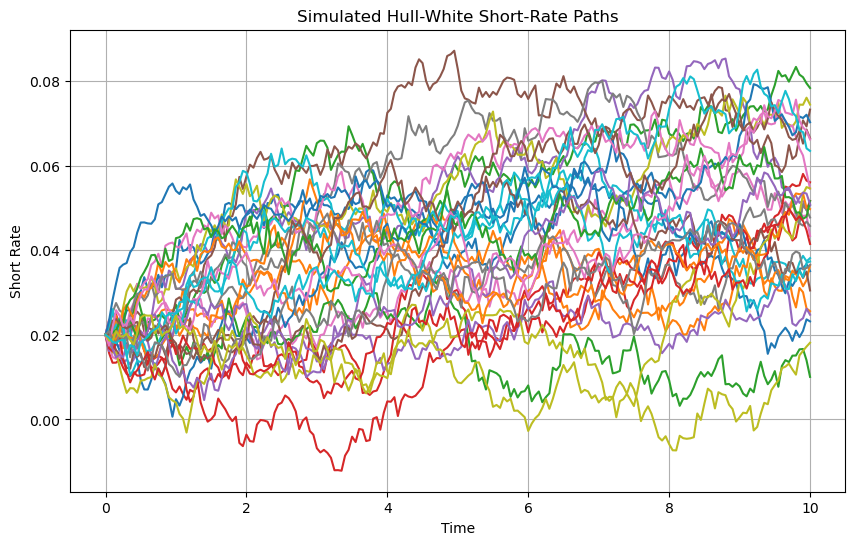

In [7]:
plot_rate_paths(
    times,
    rate_paths,
    n_plot=30
)

---
# 6. LSM Algorithm

At each exercise date, LSM compares:

```text
Immediate exercise value
vs
Estimated continuation value
```

The immediate exercise value is known path by path:

$$
E_t=\max(V_{swap}(t),0).
$$

The continuation value is estimated by regression:

$$
C_t \approx \beta_0 + \beta_1 X_t + \beta_2 X_t^2 + \cdots.
$$

Exercise occurs when:

$$
E_t > \widehat{C}_t.
$$

---
# 7. Base LSM Price

The default basis uses both the short rate and forward swap rate.

In [8]:
lsm_pricer = BermudanSwaptionLSMPricer(
    model=hw_model,
    instrument=bermudan,
    times=times,
    rate_paths=rate_paths,
    basis_type="rate_swap",
    basis_degree=2
)

lsm_price = lsm_pricer.price()

print_lsm_summary(
    lsm_price,
    lsm_pricer
)

Bermudan Swaption LSM Pricing Summary
Price       : 16,316.380921
Basis type  : rate_swap
Basis degree: 2
Paths       : 20000
Steps       : 200


---
# 8. Exercise Distribution

The LSM pricer records the first exercise time for each simulated path.

In [9]:
exercise_df = lsm_pricer.exercise_summary()

print_exercise_summary(
    exercise_df
)

exercise_df

Exercise Summary
   time  exercise_count  exercise_ratio
0   1.0              15         0.00075
1   2.0             160         0.00800
2   3.0             624         0.03120
3   4.0            1192         0.05960
4   5.0            4687         0.23435
5   NaN           13322         0.66610


,time,exercise_count,exercise_ratio
0,1.0,15,0.00075
1,2.0,160,0.00800
2,3.0,624,0.03120
3,4.0,1192,0.05960
4,5.0,4687,0.23435
5,NaN,13322,0.66610


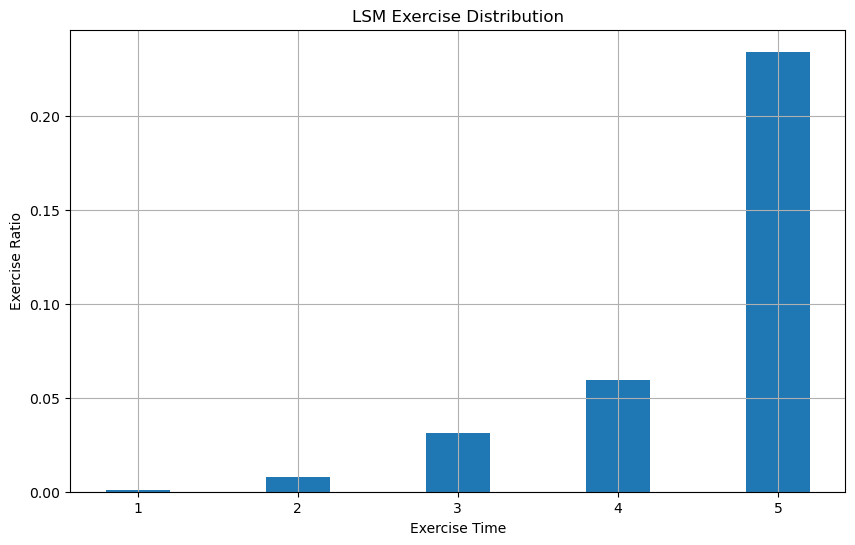

In [10]:
plot_exercise_distribution(
    exercise_df
)

---
# 9. Regression Diagnostics

At each exercise date, LSM regresses discounted future cashflows on state variables using in-the-money paths.

In [11]:
regression_df = regression_diagnostics_table(
    lsm_pricer
)

regression_df

,exercise_time,n_regression_paths,basis_type,basis_degree,n_coefficients,coefficients
0,4.0,5821,rate_swap,2,6,"[-197715.21631993048, -822724.6062136263, 5738..."
1,3.0,5064,rate_swap,2,6,"[-176374.29091834277, -1746589.9965311214, 611..."
2,2.0,4104,rate_swap,2,6,"[-153404.80135212519, -1800477.0600885851, 575..."
3,1.0,2808,rate_swap,2,6,"[-137703.0013970308, -1277552.7049817573, 5085..."


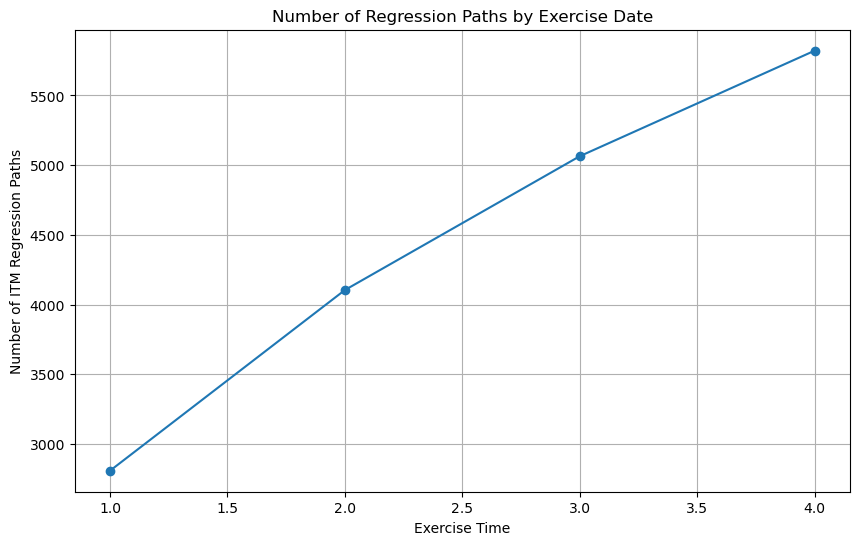

In [12]:
if len(regression_df) > 0:
    plot_regression_path_counts(
        regression_df
    )
else:
    print("No regression diagnostics available.")

---
# 10. Compare with Chapter 11 Tree Price

The tree and LSM prices should not match exactly because the numerical methods are different.

In [13]:
tree = HullWhiteBinomialTree(
    model=hw_model,
    maturity=5.0,
    n_steps=80,
    r0=r0
)

tree_pricer = BermudanSwaptionTreePricer(
    tree=tree,
    bermudan_swaption=bermudan
)

tree_price = tree_pricer.price()

compare_tree_lsm_prices(
    tree_price,
    lsm_price
)

Tree vs LSM Comparison
Tree price : 12,704.518629
LSM price  : 16,316.380921
Difference : 3,611.862292


---
# 11. Basis Function Sensitivity

We compare three basis choices:

```text
rate
swap
rate_swap
```

In [14]:
basis_types = [
    "rate",
    "swap",
    "rate_swap"
]

rows = []

for basis in basis_types:

    pricer_basis = BermudanSwaptionLSMPricer(
        model=hw_model,
        instrument=bermudan,
        times=times,
        rate_paths=rate_paths,
        basis_type=basis,
        basis_degree=2
    )

    price_basis = pricer_basis.price()

    rows.append(
        {
            "basis_type": basis,
            "price": price_basis
        }
    )

basis_df = pd.DataFrame(rows)

basis_df

,basis_type,price
0,rate,13194.172032
1,swap,15624.966038
2,rate_swap,16316.380921


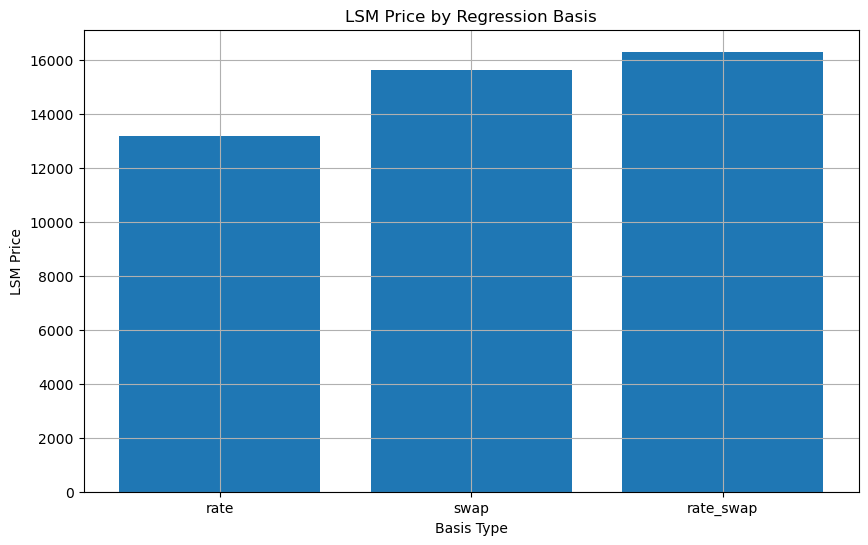

In [15]:
plt.figure()

plt.bar(
    basis_df["basis_type"],
    basis_df["price"]
)

plt.title("LSM Price by Regression Basis")
plt.xlabel("Basis Type")
plt.ylabel("LSM Price")
plt.grid()
plt.show()

---
# 12. Polynomial Degree Sensitivity

Higher-degree basis functions may capture nonlinear continuation values, but can also overfit simulation noise.

In [16]:
degrees = [
    1,
    2,
    3
]

rows = []

for degree in degrees:

    pricer_degree = BermudanSwaptionLSMPricer(
        model=hw_model,
        instrument=bermudan,
        times=times,
        rate_paths=rate_paths,
        basis_type="rate_swap",
        basis_degree=degree
    )

    price_degree = pricer_degree.price()

    rows.append(
        {
            "basis_degree": degree,
            "price": price_degree
        }
    )

degree_df = pd.DataFrame(rows)

degree_df

,basis_degree,price
0,1,16304.046072
1,2,16316.380921
2,3,16316.333056


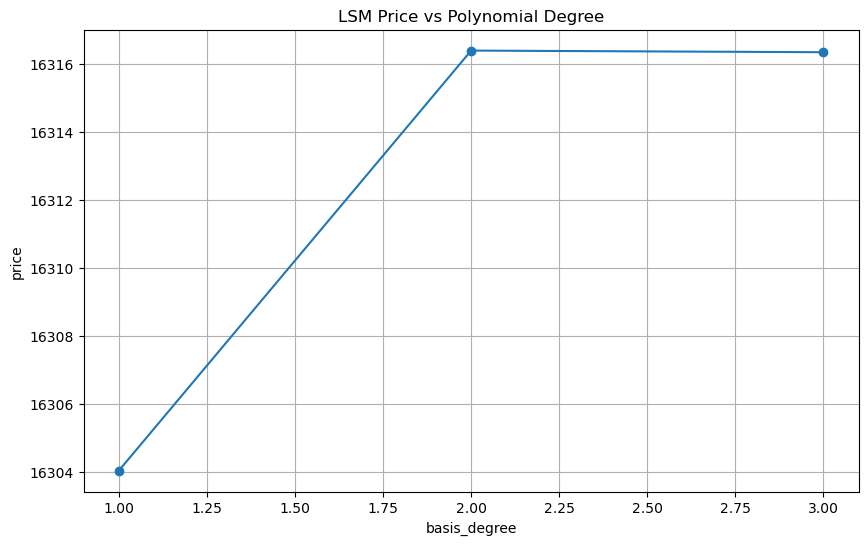

In [17]:
plot_price_sensitivity(
    degree_df,
    x_col="basis_degree",
    y_col="price",
    title="LSM Price vs Polynomial Degree"
)

---
# 13. Number of Paths Sensitivity

More paths reduce Monte Carlo noise and improve regression stability, but increase runtime.

In [18]:
path_counts = [
    2000,
    5000,
    10000,
    20000
]

rows = []

for n in path_counts:

    times_n, paths_n = simulate_hull_white_paths_for_lsm(
        model=hw_model,
        r0=r0,
        maturity=simulation_maturity,
        n_steps=n_steps,
        n_paths=n,
        seed=42
    )

    pricer_n = BermudanSwaptionLSMPricer(
        model=hw_model,
        instrument=bermudan,
        times=times_n,
        rate_paths=paths_n,
        basis_type="rate_swap",
        basis_degree=2
    )

    price_n = pricer_n.price()

    rows.append(
        {
            "n_paths": n,
            "price": price_n
        }
    )

path_df = pd.DataFrame(rows)

path_df

,n_paths,price
0,2000,16580.279899
1,5000,15900.721364
2,10000,15607.136541
3,20000,16316.380921


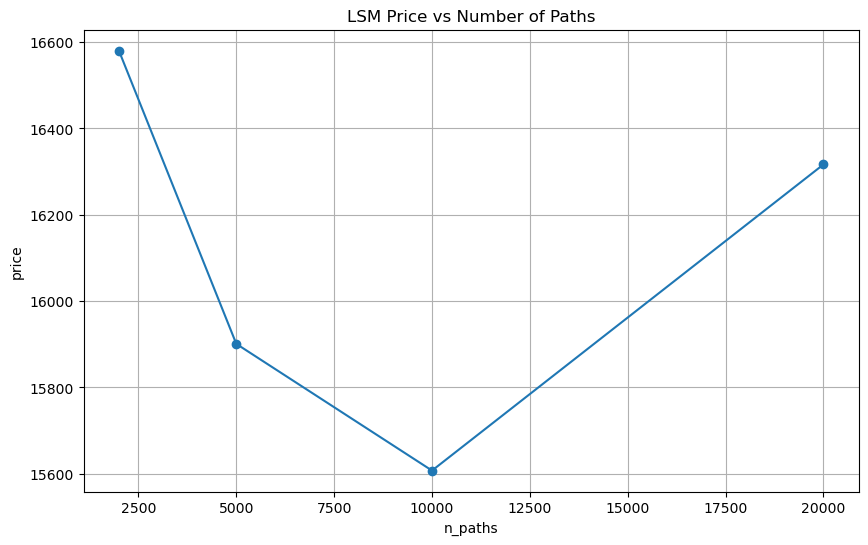

In [19]:
plot_price_sensitivity(
    path_df,
    x_col="n_paths",
    y_col="price",
    title="LSM Price vs Number of Paths"
)

---
# 14. Fixed Rate Sensitivity

For a payer Bermudan swaption, a lower fixed rate generally increases option value.

In [20]:
fixed_rates = [
    0.035,
    0.040,
    0.045,
    0.050,
    0.055
]

rows = []

for K in fixed_rates:

    instrument_K = BermudanSwaption(
        notional=1_000_000,
        fixed_rate=K,
        option_start=1.0,
        option_end=5.0,
        swap_tenor=5.0,
        payment_frequency=2,
        exercise_frequency=1,
        payer=True
    )

    pricer_K = BermudanSwaptionLSMPricer(
        model=hw_model,
        instrument=instrument_K,
        times=times,
        rate_paths=rate_paths,
        basis_type="rate_swap",
        basis_degree=2
    )

    price_K = pricer_K.price()

    rows.append(
        {
            "fixed_rate": K,
            "price": price_K
        }
    )

fixed_rate_df = pd.DataFrame(rows)

fixed_rate_df

,fixed_rate,price
0,0.035,32149.227129
1,0.040,23291.366679
2,0.045,16316.380921
3,0.050,11033.656493
4,0.055,7162.273462


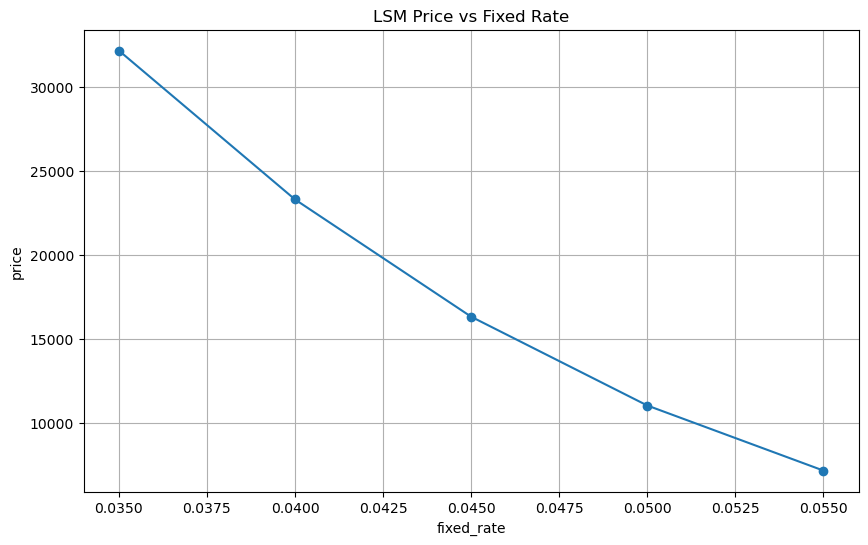

In [21]:
plot_price_sensitivity(
    fixed_rate_df,
    x_col="fixed_rate",
    y_col="price",
    title="LSM Price vs Fixed Rate"
)

---
# 15. Volatility Sensitivity

Higher Hull-White volatility usually increases Bermudan swaption value because the product contains embedded optionality.

In [22]:
volatilities = [
    0.005,
    0.010,
    0.015,
    0.020
]

rows = []

for sigma in volatilities:

    model_sigma = HullWhiteModel(
        mean_reversion=0.05,
        volatility=sigma,
        curve=curve
    )

    r0_sigma = model_sigma.instantaneous_forward_rate(
        1e-6
    )

    times_sigma, paths_sigma = simulate_hull_white_paths_for_lsm(
        model=model_sigma,
        r0=r0_sigma,
        maturity=simulation_maturity,
        n_steps=n_steps,
        n_paths=10000,
        seed=42
    )

    pricer_sigma = BermudanSwaptionLSMPricer(
        model=model_sigma,
        instrument=bermudan,
        times=times_sigma,
        rate_paths=paths_sigma,
        basis_type="rate_swap",
        basis_degree=2
    )

    price_sigma = pricer_sigma.price()

    rows.append(
        {
            "sigma": sigma,
            "price": price_sigma
        }
    )

vol_df = pd.DataFrame(rows)

vol_df

,sigma,price
0,0.005,2746.365445
1,0.010,15607.136541
2,0.015,31998.335073
3,0.020,49542.468700


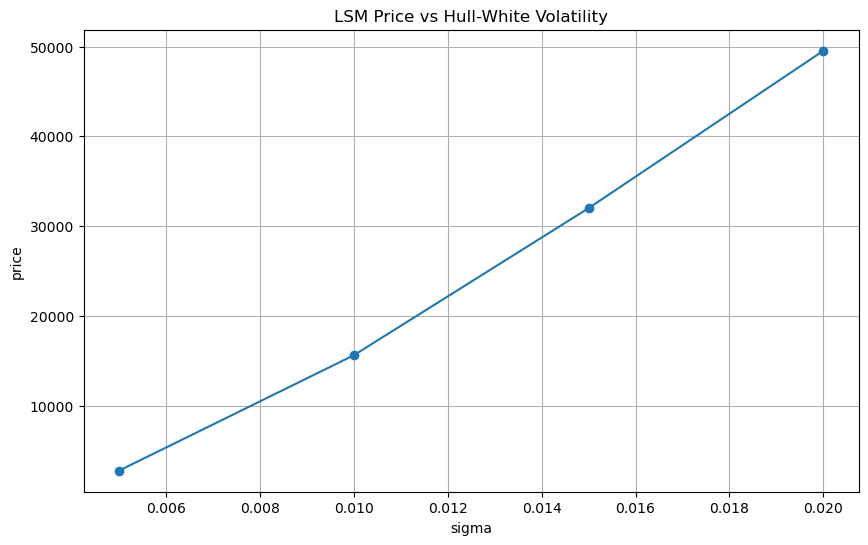

In [23]:
plot_price_sensitivity(
    vol_df,
    x_col="sigma",
    y_col="price",
    title="LSM Price vs Hull-White Volatility"
)

---
# 16. Interpretation

Tree pricing and LSM pricing solve the same mathematical problem:

$$
V(t)=\max(\text{exercise now}, \text{continue}).
$$

They differ in how continuation value is computed.

## Tree Method

```text
Continuation value = discounted expectation from neighboring tree nodes
```

## LSM Method

```text
Continuation value = regression estimate from simulated paths
```

LSM is more flexible, especially for high-dimensional models, but introduces simulation and regression error.

---
# 17. Limitations

This implementation is educational.

Important limitations:

1. The simulated rate model is one-factor Hull-White.
2. Pathwise discount bonds are approximated from simulated short rates.
3. Regression basis choice affects results.
4. Monte Carlo noise can be material.
5. No variance reduction is used.
6. No calibration to a real swaption cube is performed.

Production LSM Bermudan pricing often uses more paths, better basis functions, antithetic variates, control variates, calibrated models, and multiple interest-rate factors.

---
# 18. Chapter Summary

This chapter implemented:

- Hull-White Monte Carlo simulation for LSM
- Bermudan swaption immediate exercise values
- pathwise swap-rate and annuity calculations
- Longstaff-Schwartz continuation-value regression
- exercise decision tracking
- comparison with tree pricing
- sensitivity analysis for basis type, degree, path count, fixed rate, and volatility

Together, Chapters 11 and 12 provide two major numerical approaches for Bermudan-style rates derivatives:

```text
Tree-based backward induction
vs
Regression-based Monte Carlo
```